# Week 7 Exercises

### Ex 7.1

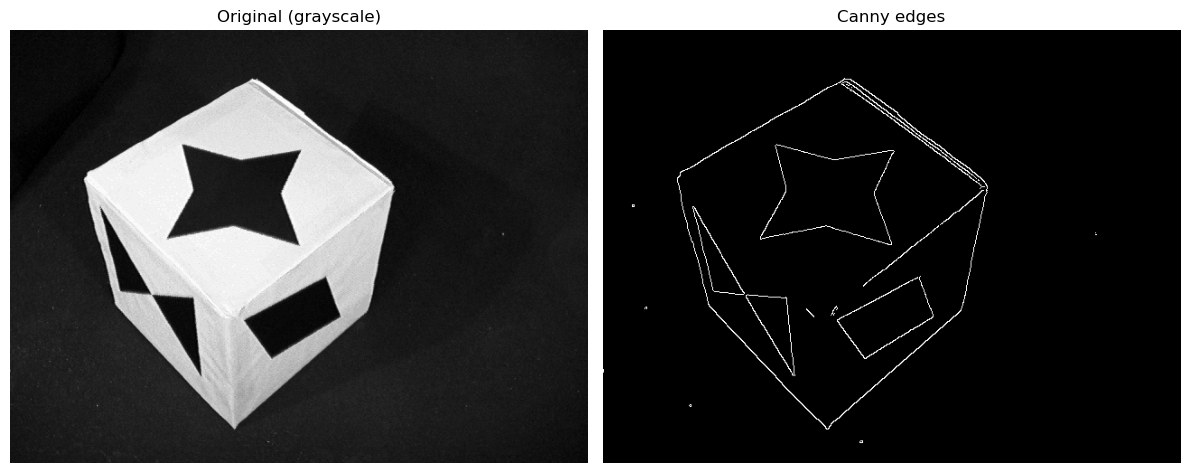

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
im = cv2.imread('Box3.bmp')
im_gray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

# Detect edges with Canny
edges = cv2.Canny(im_gray, threshold1=100, threshold2=200)

# Visualize
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(im_gray, cmap='gray')
ax[0].set_title('Original (grayscale)')
ax[0].axis('off')

ax[1].imshow(edges, cmap='gray')
ax[1].set_title('Canny edges')
ax[1].axis('off')

plt.tight_layout()
plt.show()

### Ex 7.2

In [14]:
import skimage

hspace, angles, dists = skimage.transform.hough_line(edges)

Hspace is the Hough space.
Angles are theta values for the lines.
Dists are the distance to the lines.

### Ex 7.3

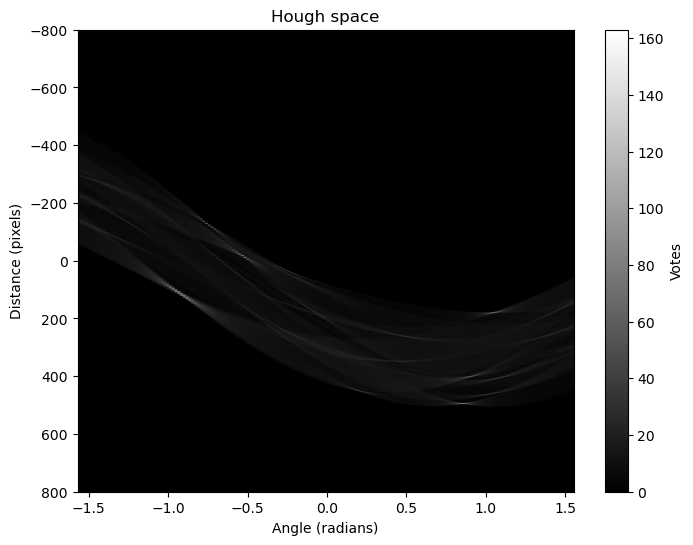

In [15]:
extent = [angles[0], angles[-1], dists[-1], dists[0]]

plt.figure(figsize=(8, 6))
plt.imshow(hspace, extent=extent, aspect='auto', cmap='gray')
plt.xlabel('Angle (radians)')
plt.ylabel('Distance (pixels)')
plt.title('Hough space')
plt.colorbar(label='Votes')
plt.show()

### Ex 7.4

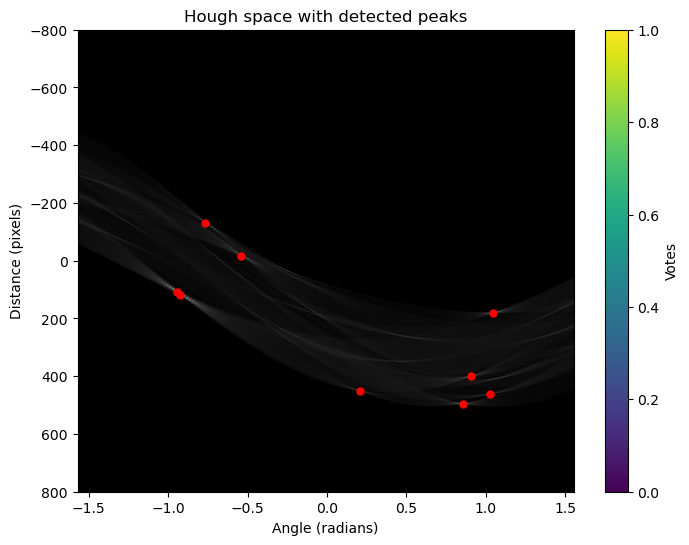

In [16]:
from skimage.transform import hough_line_peaks

# Since the box has 9 straight edges (3 visible faces x ~3 edges, shared edges),
# start with n=9 or so and adjust based on results
n = 9
extH, extAngles, extDists = hough_line_peaks(hspace, angles, dists, num_peaks=n)

# Visualize peaks on top of the Hough space
plt.figure(figsize=(8, 6))
plt.imshow(hspace, extent=extent, aspect='auto', cmap='gray')
plt.scatter(extAngles, extDists, color='red', marker='.', s=100)
plt.xlabel('Angle (radians)')
plt.ylabel('Distance (pixels)')
plt.title('Hough space with detected peaks')
plt.colorbar(label='Votes')
plt.show()

### Ex 7.5

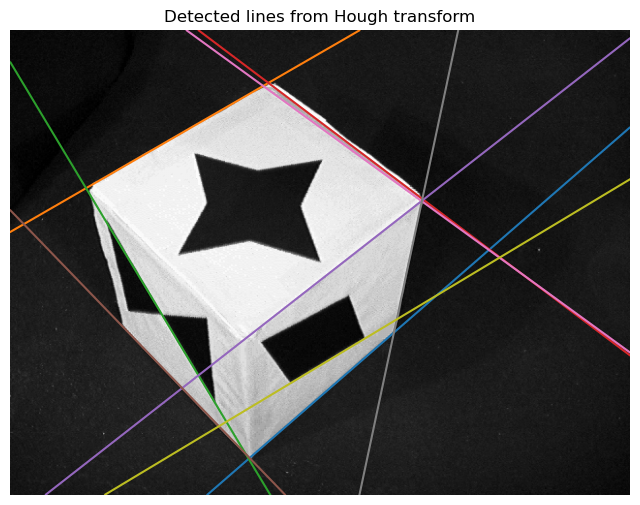

In [17]:
def DrawLine(l, shape):
    #Checks where the line intersects the four sides of the image
    # and finds the two intersections that are within the frame
    def in_frame(l_im):
        q = np.cross(l.flatten(), l_im)
        q = q[:2]/q[2]
        if all(q>=0) and all(q+1<=shape[1::-1]):
            return q
    lines = [[1, 0, 0], [0, 1, 0], [1, 0, 1-shape[1]], [0, 1, 1-shape[0]]]
    P = [in_frame(l_im) for l_im in lines if in_frame(l_im) is not None]
    if (len(P)==0):
        print("Line is completely outside image")
    plt.plot(*np.array(P).T)


# Display the original image with detected lines overlaid
plt.figure(figsize=(8, 8))
plt.imshow(im_gray, cmap='gray')

for theta, rho in zip(extAngles, extDists):
    # Convert (theta, rho) into homogeneous line coefficients:
    # rho = x*cos(theta) + y*sin(theta)  ->  x*cos(theta) + y*sin(theta) - rho = 0
    l = np.array([np.cos(theta), np.sin(theta), -rho])
    DrawLine(l, im_gray.shape)

plt.title('Detected lines from Hough transform')
plt.axis('off')
plt.show()

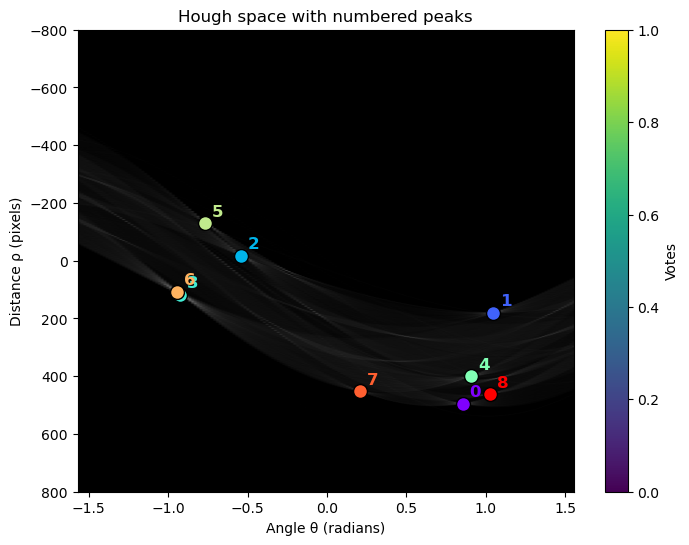

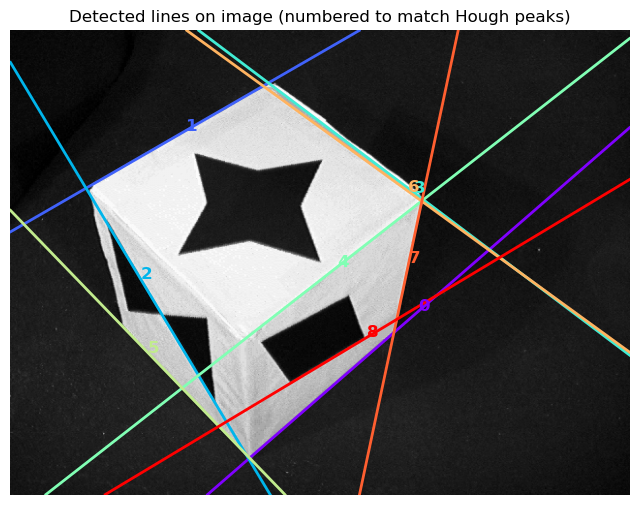

Line #  θ (rad)     ρ (px)    
0       0.855       495.0     
1       1.047       180.0     
2       -0.541      -17.0     
3       -0.925      117.0     
4       0.908       400.0     
5       -0.768      -129.0    
6       -0.942      107.0     
7       0.209       452.0     
8       1.030       461.0     


In [18]:
import matplotlib.cm as cm

n = len(extAngles)
colors = cm.rainbow(np.linspace(0, 1, n))

# --- Hough space with numbered peaks ---
plt.figure(figsize=(8, 6))
plt.imshow(hspace, extent=extent, aspect='auto', cmap='gray')
for i, (theta, rho) in enumerate(zip(extAngles, extDists)):
    plt.scatter(theta, rho, color=colors[i], s=100, edgecolor='black', zorder=3)
    plt.annotate(str(i), (theta, rho), color=colors[i], fontsize=12,
                 fontweight='bold', xytext=(5, 5), textcoords='offset points')
plt.xlabel('Angle θ (radians)')
plt.ylabel('Distance ρ (pixels)')
plt.title('Hough space with numbered peaks')
plt.colorbar(label='Votes')
plt.show()

# --- Original image with matching numbered lines ---
plt.figure(figsize=(8, 8))
plt.imshow(im_gray, cmap='gray')
for i, (theta, rho) in enumerate(zip(extAngles, extDists)):
    l = np.array([np.cos(theta), np.sin(theta), -rho])
    plt.gca().set_prop_cycle(None)  # reset so DrawLine's plot doesn't clash
    plt.plot([], [])  # placeholder if needed
    # draw manually with the right color instead of relying on DrawLine's default color
    def in_frame(l_im, shape):
        q = np.cross(l.flatten(), l_im)
        q = q[:2]/q[2]
        if all(q>=0) and all(q+1<=shape[1::-1]):
            return q
    lines = [[1,0,0],[0,1,0],[1,0,1-im_gray.shape[1]],[0,1,1-im_gray.shape[0]]]
    P = [in_frame(l_im, im_gray.shape) for l_im in lines if in_frame(l_im, im_gray.shape) is not None]
    if len(P) == 2:
        P = np.array(P)
        plt.plot(P[:,0], P[:,1], color=colors[i], linewidth=2)
        mid = P.mean(axis=0)
        plt.annotate(str(i), mid, color=colors[i], fontsize=12, fontweight='bold')

plt.title('Detected lines on image (numbered to match Hough peaks)')
plt.axis('off')
plt.show()

# --- Print table of correspondences ---
print(f"{'Line #':<8}{'θ (rad)':<12}{'ρ (px)':<10}")
for i, (theta, rho) in enumerate(zip(extAngles, extDists)):
    print(f"{i:<8}{theta:<12.3f}{rho:<10.1f}")

### Ex 7.6

In [19]:
def test_points(n_in, n_out):
    a = (np.random.rand(n_in)-.5)*10
    b = np.vstack((a, a*.5+np.random.randn(n_in)*.25))
    points = np.hstack((b, 2*np.random.randn(2, n_out)))
    return np.random.permutation(points.T).T

In [20]:
def fit_line(p1, p2):
    """
    Fits a line through two points, given in homogeneous coordinates.
    
    p1, p2: 2D points, either inhomogeneous (2,) or homogeneous (3,)
    Returns: line l = [a, b, c] such that a*x + b*y + c = 0, normalized
             so that (a, b) is a unit normal vector.
    """
    # Convert to homogeneous if needed
    if p1.shape[0] == 2:
        p1 = np.append(p1, 1)
    if p2.shape[0] == 2:
        p2 = np.append(p2, 1)
    
    l = np.cross(p1, p2)
    
    # Normalize so (a,b) is a unit vector -> makes distance formula easy later
    l = l / np.linalg.norm(l[:2])
    
    return l

### Ex 7.7

In [21]:
def find_inliers(l, points, threshold):
    """
    Determines which points are inliers vs outliers with respect to a line.
    
    l: normalized line [a, b, c], with (a,b) a unit vector
    points: (2, n) inhomogeneous points
    threshold: max perpendicular distance to be considered an inlier
    
    Returns: boolean array (n,) — True where point is an inlier
    """
    points_h = np.vstack((points, np.ones(points.shape[1])))
    dists = np.abs(l @ points_h)
    inliers = dists < threshold
    return inliers

### Ex 7.8

In [22]:
def consensus(l, points, threshold):
    """
    Calculates the consensus (number of inliers) for a line with respect to a set of points.
    
    l: normalized line [a, b, c]
    points: (2, n) inhomogeneous points
    threshold: max perpendicular distance to be considered an inlier
    
    Returns: int — number of inlier points
    """
    inliers = find_inliers(l, points, threshold)
    return np.sum(inliers)

### Ex 7.9

In [23]:
def sample_two_points(points):
    """
    Randomly samples two of n 2D points without replacement.
    
    points: (2, n) inhomogeneous points
    
    Returns: p1, p2 — two distinct points, each shape (2,)
    """
    n = points.shape[1]
    idx = np.random.choice(n, size=2, replace=False)
    p1 = points[:, idx[0]]
    p2 = points[:, idx[1]]
    return p1, p2

### Ex 7.10

Best line: [ 0.4431878  -0.89642879 -0.10262133]
Consensus (# inliers): 131 / 200


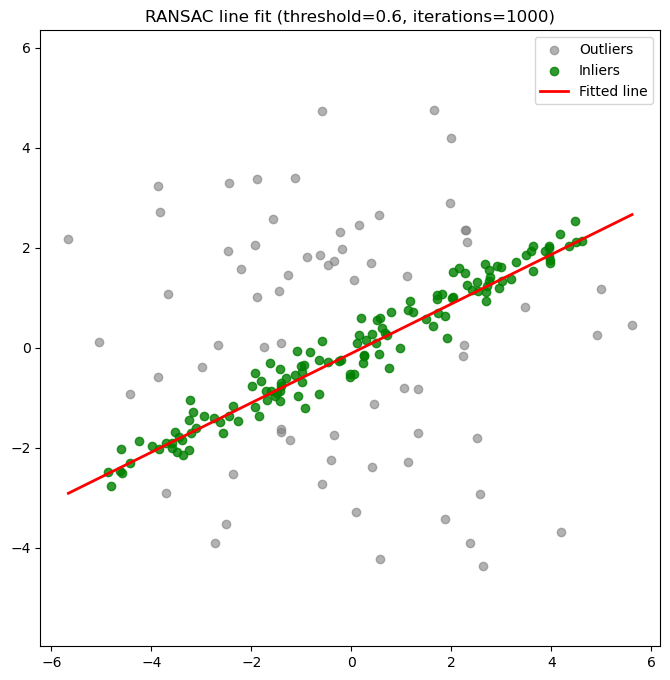

In [24]:
def ransac_line(points, threshold, n_iterations):
    """
    RANSAC algorithm for fitting a line to 2D points with outliers.
    
    points: (2, n) inhomogeneous points
    threshold: max perpendicular distance to count as an inlier
    n_iterations: number of random samples to try
    
    Returns:
        best_line: [a, b, c], the line with the highest consensus
        best_inliers: boolean array (n,) marking inliers of best_line
        best_consensus: int, number of inliers for best_line
    """
    best_consensus = -1
    best_line = None
    best_inliers = None
    
    for i in range(n_iterations):
        p1, p2 = sample_two_points(points)
        l = fit_line(p1, p2)
        c = consensus(l, points, threshold)
        
        if c > best_consensus:
            best_consensus = c
            best_line = l
            best_inliers = find_inliers(l, points, threshold)
    
    return best_line, best_inliers, best_consensus


# --- Test on generated data ---
points = test_points(n_in=100, n_out=100)

threshold = 0.6   # tune manually
n_iterations = 1000  # tune manually

best_line, best_inliers, best_consensus = ransac_line(points, threshold, n_iterations)

print(f"Best line: {best_line}")
print(f"Consensus (# inliers): {best_consensus} / {points.shape[1]}")

# --- Visualize ---
plt.figure(figsize=(8, 8))
plt.scatter(points[0, ~best_inliers], points[1, ~best_inliers], c='gray', label='Outliers', alpha=0.6)
plt.scatter(points[0, best_inliers], points[1, best_inliers], c='green', label='Inliers', alpha=0.8)

# Draw the fitted line across the plot range
x_range = np.array([points[0].min(), points[0].max()])
a, b, c = best_line
if abs(b) > 1e-6:
    y_range = -(a * x_range + c) / b
    plt.plot(x_range, y_range, 'r-', linewidth=2, label='Fitted line')
else:
    x_val = -c / a
    plt.axvline(x_val, color='r', linewidth=2, label='Fitted line')

plt.legend()
plt.axis('equal')
plt.title(f'RANSAC line fit (threshold={threshold}, iterations={n_iterations})')
plt.show()

### Ex 7.11

Best line: [-0.52801774  0.84923334 -0.19710287]
Consensus (# inliers): 140 / 200


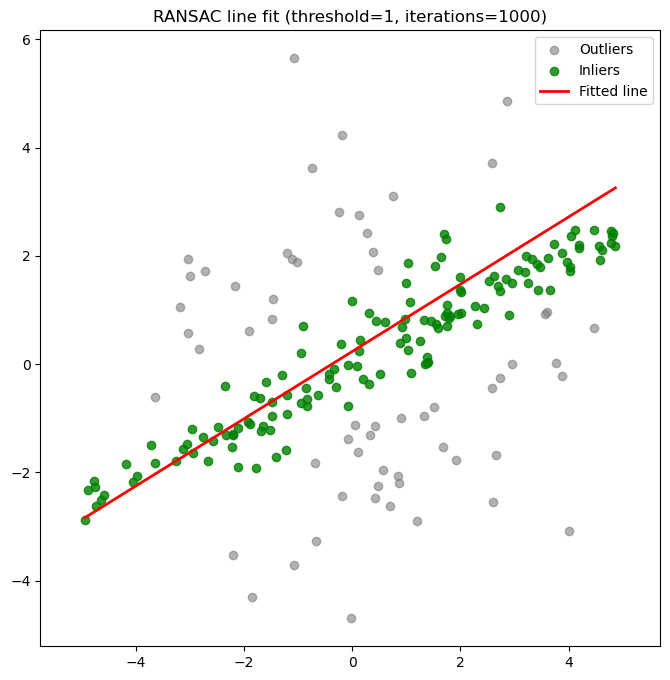

In [30]:
# --- Test on generated data ---
points = test_points(n_in=100, n_out=100)

threshold = 1   # tune manually
n_iterations = 1000  # tune manually

best_line, best_inliers, best_consensus = ransac_line(points, threshold, n_iterations)

print(f"Best line: {best_line}")
print(f"Consensus (# inliers): {best_consensus} / {points.shape[1]}")

# --- Visualize ---
plt.figure(figsize=(8, 8))
plt.scatter(points[0, ~best_inliers], points[1, ~best_inliers], c='gray', label='Outliers', alpha=0.6)
plt.scatter(points[0, best_inliers], points[1, best_inliers], c='green', label='Inliers', alpha=0.8)

# Draw the fitted line across the plot range
x_range = np.array([points[0].min(), points[0].max()])
a, b, c = best_line
if abs(b) > 1e-6:
    y_range = -(a * x_range + c) / b
    plt.plot(x_range, y_range, 'r-', linewidth=2, label='Fitted line')
else:
    x_val = -c / a
    plt.axvline(x_val, color='r', linewidth=2, label='Fitted line')

plt.legend()
plt.axis('equal')
plt.title(f'RANSAC line fit (threshold={threshold}, iterations={n_iterations})')
plt.show()

### 7.12

RANSAC line (2-point fit): [-0.46771511  0.88387928  0.01401352]
Refined line (PCA on inliers): [ 0.44695234 -0.89455777 -0.02882071]
Consensus: 126 / 200


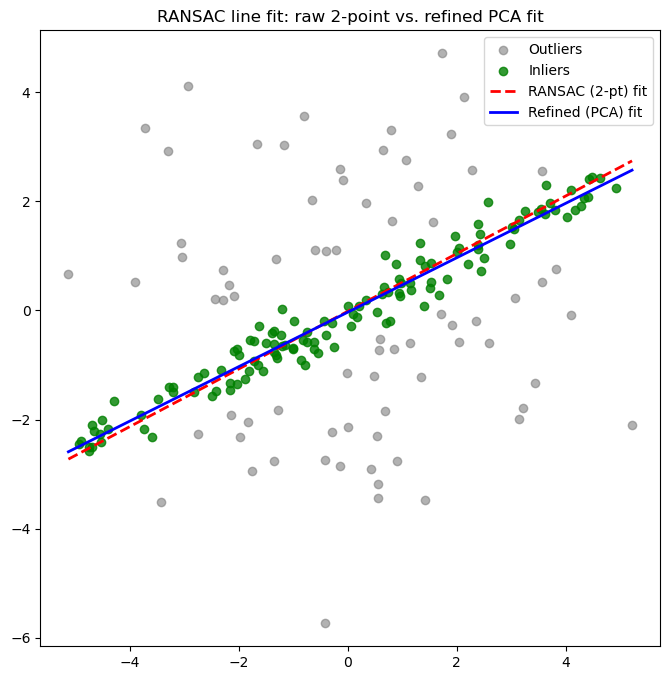

In [38]:
def pca_line(x):  # assumes x is a (2 x n) array of points
    d = np.cov(x)[:, 0]
    d /= np.linalg.norm(d)
    l = [d[1], -d[0]]
    l.append(-(l@x.mean(1)))
    return l


def ransac_line(points, threshold, n_iterations):
    """
    RANSAC algorithm for fitting a line to 2D points with outliers,
    with a final least-squares refit on the inlier set.
    """
    best_consensus = -1
    best_line = None
    best_inliers = None
    
    for i in range(n_iterations):
        p1, p2 = sample_two_points(points)
        l = fit_line(p1, p2)
        c = consensus(l, points, threshold)
        
        if c > best_consensus:
            best_consensus = c
            best_line = l
            best_inliers = find_inliers(l, points, threshold)
    
    # Final step: refit using total least squares (PCA) on all inliers
    inlier_points = points[:, best_inliers]
    refined_line = np.array(pca_line(inlier_points))
    refined_line = refined_line / np.linalg.norm(refined_line[:2])  # normalize (a,b) to unit
    
    return best_line, best_inliers, best_consensus, refined_line


# --- Test on generated data ---
points = test_points(n_in=100, n_out=100)
threshold = 0.6
n_iterations = 1000

best_line, best_inliers, best_consensus, refined_line = ransac_line(points, threshold, n_iterations)

print(f"RANSAC line (2-point fit): {best_line}")
print(f"Refined line (PCA on inliers): {refined_line}")
print(f"Consensus: {best_consensus} / {points.shape[1]}")

# --- Visualize both lines ---
plt.figure(figsize=(8, 8))
plt.scatter(points[0, ~best_inliers], points[1, ~best_inliers], c='gray', label='Outliers', alpha=0.6)
plt.scatter(points[0, best_inliers], points[1, best_inliers], c='green', label='Inliers', alpha=0.8)

x_range = np.array([points[0].min(), points[0].max()])

for l, style, label in [(best_line, 'r--', 'RANSAC (2-pt) fit'),
                          (refined_line, 'b-', 'Refined (PCA) fit')]:
    a, b, c = l
    if abs(b) > 1e-6:
        y_range = -(a * x_range + c) / b
        plt.plot(x_range, y_range, style, linewidth=2, label=label)
    else:
        plt.axvline(-c/a, color=style[0], linewidth=2, label=label)

plt.legend()
plt.axis('equal')
plt.title('RANSAC line fit: raw 2-point vs. refined PCA fit')
plt.show()

### Ex 7.13

Stopped after 9 iterations (N_hat=8.9)
RANSAC line (2-point fit): [-0.4133454   0.91057431 -0.04751499]
Refined line (PCA on inliers): [ 0.44563035 -0.89521706  0.01694129]
Consensus: 127 / 200


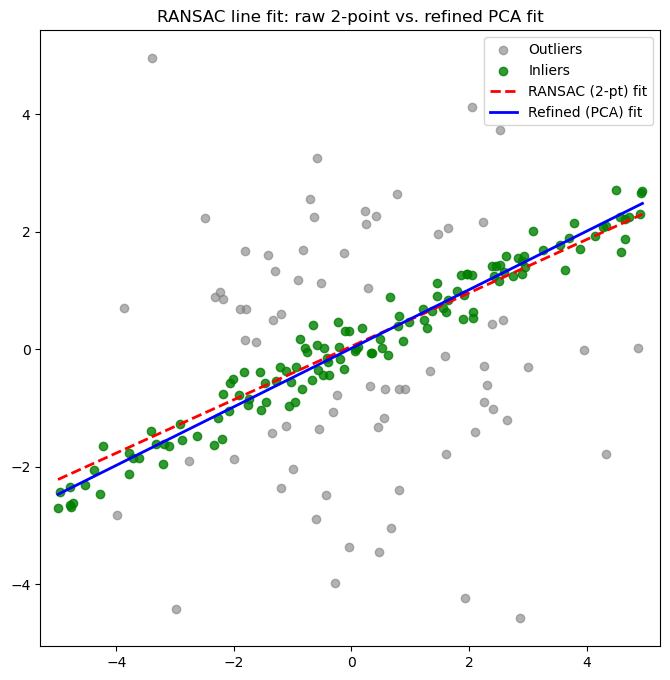

In [45]:
def ransac_line(points, threshold, n_iterations, p=0.99):
    """
    RANSAC algorithm for fitting a line to 2D points with outliers,
    with adaptive stopping criteria (slide notation) and PCA refit.
    """
    best_consensus = -1   # this is 's' in the slide
    best_line = None
    best_inliers = None
    
    n = 2  # minimal sample size needed to fit a line
    m = points.shape[1]  # total number of data points
    N_hat = n_iterations  # start with a cap, shrinks as we find better models
    
    i = 0
    while i < min(n_iterations, N_hat):
        p1, p2 = sample_two_points(points)
        l = fit_line(p1, p2)
        c = consensus(l, points, threshold)
        
        if c > best_consensus:
            best_consensus = c  # s
            best_line = l
            best_inliers = find_inliers(l, points, threshold)
            
            # eps_hat = 1 - s/m   (upper bound estimate of true outlier ratio)
            eps_hat = 1 - (best_consensus / m)
            eps_hat = min(eps_hat, 1 - 1e-6)  # guard against log(0)
            
            # N_hat = log(1-p) / log(1 - (1-eps_hat)^n)
            denom = np.log(1 - (1 - eps_hat)**n)
            if denom < 0:
                N_hat = np.log(1 - p) / denom
        
        i += 1
    
    print(f"Stopped after {i} iterations (N_hat={N_hat:.1f})")
    
    inlier_points = points[:, best_inliers]
    refined_line = np.array(pca_line(inlier_points))
    refined_line = refined_line / np.linalg.norm(refined_line[:2])
    
    return best_line, best_inliers, best_consensus, refined_line

# --- Test on generated data ---
points = test_points(n_in=100, n_out=100)
threshold = 0.6
n_iterations = 1000

best_line, best_inliers, best_consensus, refined_line = ransac_line(points, threshold, n_iterations)

print(f"RANSAC line (2-point fit): {best_line}")
print(f"Refined line (PCA on inliers): {refined_line}")
print(f"Consensus: {best_consensus} / {points.shape[1]}")

# --- Visualize both lines ---
plt.figure(figsize=(8, 8))
plt.scatter(points[0, ~best_inliers], points[1, ~best_inliers], c='gray', label='Outliers', alpha=0.6)
plt.scatter(points[0, best_inliers], points[1, best_inliers], c='green', label='Inliers', alpha=0.8)

x_range = np.array([points[0].min(), points[0].max()])

for l, style, label in [(best_line, 'r--', 'RANSAC (2-pt) fit'),
                          (refined_line, 'b-', 'Refined (PCA) fit')]:
    a, b, c = l
    if abs(b) > 1e-6:
        y_range = -(a * x_range + c) / b
        plt.plot(x_range, y_range, style, linewidth=2, label=label)
    else:
        plt.axvline(-c/a, color=style[0], linewidth=2, label=label)

plt.legend()
plt.axis('equal')
plt.title('RANSAC line fit: raw 2-point vs. refined PCA fit')
plt.show()